In [3]:
import pandas as pd
import numpy as np
from statsmodels.regression.mixed_linear_model import MixedLM
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.mixed_linear_model import MixedLM
import statsmodels.api as sm
sns.set_style("white")
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests
import os

In [ ]:
SEED = 38
model_type = 'C-GMVAE'
run_where = 'local' # tell if I'm running locally or on Great Lakes

if run_where == 'local':
    file_path = '/home/nghayes/latent-space-trajectories/latent_variables_epoch20000.csv'
elif run_where == 'great-lakes':
    default_path = f'/nfs/turbo/umms-kaczoro/u19-shared/vae-HC-PFC/14mon_ADBXD_joined/seed_model/{model_type}_SEED_{SEED}'
    file_path = os.path.join(default_path, 'latent_variables_epoch20000.csv')

df = pd.read_csv(file_path, index_col=0)

In [71]:
# df: starting with latent space data, which will get edited with PP info
# want to create two new data frames:
# df_latent: a new data frame from df, which will end up with decoded cfm info
# df_recons: a new data frame from the reconstruction data
LATENT_DIM = 10
RECONS_DATA_CSV  = '/home/nghayes/latent-space-trajectories/recons_cfm.csv'

print(df['14-6-Bin'].value_counts())
print(df.describe())
df_latent = df.copy()
cols = list(df_latent.columns[:LATENT_DIM]) + ["14-6-Bin"] # only want 10 LVs + which bin each observation is in
df_latent = df_latent[cols].copy()
df_latent.columns = [f"z_{i+1}" for i in range(LATENT_DIM)] + ["label"] # changing names of columns to z_i

df_recons = pd.read_csv(RECONS_DATA_CSV, index_col=0)
df_recons = df_recons.loc[df_recons['epoch'] == 20000] # I added this to choose last epoch
df_latent['decoded_cfm'] = df_recons['cfm'].values # creating new column with decoded cfm values from recons csv

14-6-Bin
2    20105
3    13668
1    11443
0    11434
Name: count, dtype: int64
                LV1           LV2           LV3           LV4           LV5  \
count  56650.000000  56650.000000  56650.000000  56650.000000  56650.000000   
mean     -20.256705    -15.159655    -11.679939     -6.995157     -1.338052   
std        8.119472      7.786041      9.916827     10.911846     11.390052   
min      -34.214813    -29.359503    -27.684828    -25.183409    -21.168283   
25%      -27.479808    -21.779699    -20.591530    -15.195161     -9.749770   
50%      -20.592559    -14.820463    -12.114686     -7.309843     -0.326291   
75%      -13.231291     -8.528811     -3.410012      0.348975      7.869470   
max       -5.473288     -1.340881      5.552579     12.048773     16.966198   

                LV6           LV7           LV8           LV9          LV10  \
count  56650.000000  56650.000000  56650.000000  56650.000000  56650.000000   
mean       1.713566      6.359805     10.704072    

/tmp/ipykernel_10410/2895561005.py:15: DtypeWarning: Columns (0: Strain) have mixed types. Specify dtype option on import or set low_memory=False.
  df_recons = pd.read_csv(RECONS_DATA_CSV, index_col=0)


In [72]:
def line_coordinates_euclidean(A, B, P):
    # A: starting point of PP axis
    # B: ending point of PP axis
    # P: point to project
    # output: point along the line (10-D coordinates), signed distance (will be PP)

    A = np.array(A)
    B = np.array(B)
    P = np.array(P)

    u_hat = (B - A) / np.linalg.norm(B - A)  # Unit direction vector from A to B
    s = np.dot(P - A, u_hat)                # Signed distance from A
    P_proj = A + s * u_hat                  # Projected point on the line

    return P_proj, s

In [73]:
def project_row(row):
    coords = row[coord_cols].values
    proj, dist = line_coordinates_euclidean(sus, res, coords)
    return pd.Series({'Projected': proj,'Signed_Distance': dist})

In [ ]:
# function for arbitrary start and end points of PP axis (not necessarily centroids of susceptible/resilient groups)
def project_row_arbitrary(row):
    coords = row[coord_cols].values
    proj, dist = line_coordinates_euclidean(start_coord, end_coord, coords)
    # also figure out what this is
    return pd.Series({'Projected': proj,'Signed_Distance': dist})

In [ ]:
coord_cols = df.columns[:10]  # First 10 columns are coordinates
df[coord_cols] = df[coord_cols].apply(pd.to_numeric, errors='coerce').fillna(0) # coerce replaces non-numeric entries with NaN

start_index = 18260
end_index = 46470

start_coord = df.loc[start_index, coord_cols].values
end_coord = df.loc[end_index, coord_cols].values

strain_order = df.sort_values('14-6-residual', ascending=True)['Strain'].unique() # order data frame by residual, then select strain column

strain_sus = strain_order[0] # choose first (most susceptible, theoretically) strain
strain_res = strain_order[-1] # choose last (most resilient, theoretically) strain

# get centroids of the susceptible and resilient strains
sus = df[df['Strain'] == strain_sus][coord_cols].apply(np.mean, axis=0).values # pick out all df rows for this strain, then grab the 10-D coords, then find average position
res = df[df['Strain'] == strain_res][coord_cols].apply(np.mean, axis=0).values

# compute how far my trajectory start/end points are from the PP axis endpoints
print('dist from trajectory start to PP start = ', np.linalg.norm(sus-start_coord))
print('dist from trajectory end to PP end = ', np.linalg.norm(res-end_coord))

# option for starting and ending at my trajectory endpoints, comment out to use PP axis
# make a function for this
sus = start_coord
res = end_coord

# don't specify start and end because function uses sus and res (maybe change this?)
projections = df.apply(project_row_arbitrary, axis=1)

df = pd.concat([
    df.reset_index(drop=True),
    pd.DataFrame(projections['Projected'].tolist(), columns=[f'Proj_{i+1}' for i in range(10)]),
    projections[['Signed_Distance']]], axis=1)

dist from trajectory start to PP start =  0.5878292963202051
dist from trajectory end to PP end =  7.449839542200349


In [ ]:
# checking that res and end_coord have same structure
print(res[0].shape)
print(end_coord[0].shape)

()

In [20]:
df.sort_values('14-6-residual', ascending=True)['14-6-residual'].unique()

array([-1.36427551, -1.31406651, -1.26961126, -0.98984271, -0.97414041,
       -0.92848383, -0.77704088, -0.67307462, -0.62782032, -0.57673104,
       -0.55246417, -0.46046176, -0.25260968, -0.23483939, -0.14823589,
       -0.11113249,  0.13390099,  0.38353629,  0.58351163,  0.58568163,
        0.66093217,  0.7382975 ,  1.04081711,  1.04391985,  1.2773932 ])

In [21]:
df[(df['14-6-residual']<1.3) & (df['14-6-residual']>1.25)]['Strain'].unique()

<StringArray>
['124']
Length: 1, dtype: str

In [22]:
df[(df['14-6-residual']<1.3) & (df['14-6-residual']>1.25)]['Strain']

8        124
18       124
62       124
82       124
92       124
        ... 
56583    124
56602    124
56610    124
56635    124
56648    124
Name: Strain, Length: 3694, dtype: str

In [23]:
df[df['Strain']=='65']['14-6-residual']

4       -1.314067
26      -1.314067
35      -1.314067
53      -0.928484
56      -1.314067
           ...   
56565   -0.928484
56601   -1.314067
56628   -0.928484
56638   -1.314067
56639   -0.928484
Name: 14-6-residual, Length: 3293, dtype: float64

In [24]:
df.loc[start_index,:]

LV1                                 -8.407204
LV2                                 -4.246681
LV3                                  2.881962
LV4                                  9.409945
LV5                                 14.161424
LV6                                 19.746548
LV7                                 26.679409
LV8                                 30.815266
LV9                                  39.04207
LV10                                44.011818
barcode            CK19021_CTACGGGCATCGGCCA-1
subclass                 019 L2/3 IT PPP Glut
cell_type                                glut
SCBID                                 CK19021
MouseID                                  2105
Age                                        14
Strain                                    161
Genotype                                    5
CFM_14_5_snRNA                      -1.625947
14-6-residual                       -1.269611
14-6-Bin                                    0
region                            

In [25]:
print(strain_order)
print(strain_sus)
print(strain_res)

<StringArray>
['83', '65', '161', '50', 'D2', '28', '39', '113', '33', 'B6', '99', '53',
 '124']
Length: 13, dtype: str
83
124


In [26]:
res

array([-32.783695, -28.24591 , -26.353554, -24.08687 , -19.939394,
       -16.430355, -14.561339,  -9.774122,  -9.151783,  -5.255166])

In [27]:
df

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,...,Proj_2,Proj_3,Proj_4,Proj_5,Proj_6,Proj_7,Proj_8,Proj_9,Proj_10,Signed_Distance
0,-24.256855,-18.943563,-19.148005,-13.069660,-7.281853,-6.647669,-1.973320,1.312754,5.479063,10.920240,...,-20.779324,-17.257867,-13.665417,-9.330025,-5.175079,-1.730611,2.853956,5.842179,10.072666,80.680860
1,-32.498856,-27.973068,-25.985146,-23.571732,-19.487030,-15.888780,-14.033054,-9.226448,-8.665678,-4.734122,...,-27.949085,-25.991966,-23.672578,-19.517632,-15.982915,-14.051269,-9.272108,-8.555716,-4.645827,115.669967
2,-17.562922,-16.157148,-7.969545,-5.897250,1.853780,4.455924,9.762284,14.726957,23.734491,29.096786,...,-13.231252,-8.062913,-3.130229,1.395130,6.203032,11.240145,15.619851,20.999778,25.567779,43.845554
3,-28.858011,-24.174309,-22.691444,-19.941648,-16.066748,-12.556651,-10.494271,-5.782712,-5.136093,-1.035175,...,-25.721719,-23.278621,-20.563742,-16.352738,-12.625340,-10.223719,-5.505011,-4.082850,-0.073363,104.800211
4,-10.571421,-6.463661,0.640753,7.082870,11.920109,17.315226,24.198599,28.219280,36.607440,41.267610,...,-5.775920,1.019065,7.275516,11.988508,17.441343,24.051534,28.228896,35.971141,40.872508,7.462832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56645,-28.579952,-23.901604,-22.118683,-19.591473,-15.684873,-12.046993,-10.108648,-5.416104,-4.710186,-0.721344,...,-25.476720,-22.980166,-20.221786,-16.004616,-12.256024,-9.802708,-5.090650,-3.590857,0.429585,103.604593
56646,-7.582398,-3.366018,3.963249,10.430345,15.107400,20.847500,27.655052,31.937830,40.201540,44.993100,...,-3.600813,3.668749,10.311412,15.079146,20.720142,27.789281,31.907609,40.339064,45.337692,-3.151896
56647,-17.119564,-13.705447,-7.196110,-4.540887,3.223161,5.727212,10.905486,15.751303,24.399230,29.637558,...,-12.570271,-7.257716,-2.207669,2.334326,7.199406,12.375987,16.737754,22.327121,26.924677,40.619907
56648,-29.270935,-24.531736,-22.611712,-20.303423,-16.054407,-12.572237,-10.648892,-5.845601,-5.259646,-1.332067,...,-25.823346,-23.402421,-20.705587,-16.497141,-12.778535,-10.398357,-5.676890,-4.286931,-0.281988,105.296159


In [28]:
coord_cols = df.columns[:10]  # First 10 columns are coordinates
df[coord_cols] = df[coord_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# order df by residual, select strain column, extract unique strain IDs
# the strain IDs should be ordered by residual, but not sure where it puts if there are repeats
strain_order = df.sort_values('14-6-residual', ascending=True)['Strain'].unique()
strain_sus = strain_order[0]
strain_res = strain_order[-1]

# finding centroid of all points in first strain and last strain
sus = df[df['Strain'] == strain_sus][coord_cols].apply(np.mean, axis=0).values
res = df[df['Strain'] == strain_res][coord_cols].apply(np.mean, axis=0).values
# finding centroid of all points in first bin and last bin
sus_cen = df[df['14-6-Bin'] == 0][coord_cols].apply(np.mean, axis=0).values
res_cen = df[df['14-6-Bin'] == 3][coord_cols].apply(np.mean, axis=0).values

# finding signed distance (PP value I think) of centers of bins and first/last strain
# maybe just to compare?
# but it's always starting and ending at first/last strain centers
_, s_sus_cen = line_coordinates_euclidean(sus, res, sus_cen)
_, s_res_cen = line_coordinates_euclidean(sus, res, res_cen)
print (s_sus_cen, s_res_cen)
_, sus_strain = line_coordinates_euclidean(sus, res, sus)
_, res_strain = line_coordinates_euclidean(sus, res, res)
print (sus_strain, res_strain)

1.3609288862339595 109.00153359470856
0.0 109.2765012533764


In [29]:
res_cen

array([-30.57590182, -25.8367872 , -24.04065523, -21.59151099,
       -17.51965438, -13.99756154, -12.06756712,  -7.29981987,
        -6.65913896,  -2.63205946])

In [30]:
# rename signed distance --> PP
df.rename(columns={df.columns[-1]: 'PP'}, inplace=True)
df

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,...,Proj_2,Proj_3,Proj_4,Proj_5,Proj_6,Proj_7,Proj_8,Proj_9,Proj_10,PP
0,-24.256855,-18.943563,-19.148005,-13.069660,-7.281853,-6.647669,-1.973320,1.312754,5.479063,10.920240,...,-20.779324,-17.257867,-13.665417,-9.330025,-5.175079,-1.730611,2.853956,5.842179,10.072666,80.680860
1,-32.498856,-27.973068,-25.985146,-23.571732,-19.487030,-15.888780,-14.033054,-9.226448,-8.665678,-4.734122,...,-27.949085,-25.991966,-23.672578,-19.517632,-15.982915,-14.051269,-9.272108,-8.555716,-4.645827,115.669967
2,-17.562922,-16.157148,-7.969545,-5.897250,1.853780,4.455924,9.762284,14.726957,23.734491,29.096786,...,-13.231252,-8.062913,-3.130229,1.395130,6.203032,11.240145,15.619851,20.999778,25.567779,43.845554
3,-28.858011,-24.174309,-22.691444,-19.941648,-16.066748,-12.556651,-10.494271,-5.782712,-5.136093,-1.035175,...,-25.721719,-23.278621,-20.563742,-16.352738,-12.625340,-10.223719,-5.505011,-4.082850,-0.073363,104.800211
4,-10.571421,-6.463661,0.640753,7.082870,11.920109,17.315226,24.198599,28.219280,36.607440,41.267610,...,-5.775920,1.019065,7.275516,11.988508,17.441343,24.051534,28.228896,35.971141,40.872508,7.462832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56645,-28.579952,-23.901604,-22.118683,-19.591473,-15.684873,-12.046993,-10.108648,-5.416104,-4.710186,-0.721344,...,-25.476720,-22.980166,-20.221786,-16.004616,-12.256024,-9.802708,-5.090650,-3.590857,0.429585,103.604593
56646,-7.582398,-3.366018,3.963249,10.430345,15.107400,20.847500,27.655052,31.937830,40.201540,44.993100,...,-3.600813,3.668749,10.311412,15.079146,20.720142,27.789281,31.907609,40.339064,45.337692,-3.151896
56647,-17.119564,-13.705447,-7.196110,-4.540887,3.223161,5.727212,10.905486,15.751303,24.399230,29.637558,...,-12.570271,-7.257716,-2.207669,2.334326,7.199406,12.375987,16.737754,22.327121,26.924677,40.619907
56648,-29.270935,-24.531736,-22.611712,-20.303423,-16.054407,-12.572237,-10.648892,-5.845601,-5.259646,-1.332067,...,-25.823346,-23.402421,-20.705587,-16.497141,-12.778535,-10.398357,-5.676890,-4.286931,-0.281988,105.296159


In [31]:
df.loc[18260, 'PP']

np.float64(-0.0)

In [32]:
df

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,...,Proj_2,Proj_3,Proj_4,Proj_5,Proj_6,Proj_7,Proj_8,Proj_9,Proj_10,PP
0,-24.256855,-18.943563,-19.148005,-13.069660,-7.281853,-6.647669,-1.973320,1.312754,5.479063,10.920240,...,-20.779324,-17.257867,-13.665417,-9.330025,-5.175079,-1.730611,2.853956,5.842179,10.072666,80.680860
1,-32.498856,-27.973068,-25.985146,-23.571732,-19.487030,-15.888780,-14.033054,-9.226448,-8.665678,-4.734122,...,-27.949085,-25.991966,-23.672578,-19.517632,-15.982915,-14.051269,-9.272108,-8.555716,-4.645827,115.669967
2,-17.562922,-16.157148,-7.969545,-5.897250,1.853780,4.455924,9.762284,14.726957,23.734491,29.096786,...,-13.231252,-8.062913,-3.130229,1.395130,6.203032,11.240145,15.619851,20.999778,25.567779,43.845554
3,-28.858011,-24.174309,-22.691444,-19.941648,-16.066748,-12.556651,-10.494271,-5.782712,-5.136093,-1.035175,...,-25.721719,-23.278621,-20.563742,-16.352738,-12.625340,-10.223719,-5.505011,-4.082850,-0.073363,104.800211
4,-10.571421,-6.463661,0.640753,7.082870,11.920109,17.315226,24.198599,28.219280,36.607440,41.267610,...,-5.775920,1.019065,7.275516,11.988508,17.441343,24.051534,28.228896,35.971141,40.872508,7.462832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56645,-28.579952,-23.901604,-22.118683,-19.591473,-15.684873,-12.046993,-10.108648,-5.416104,-4.710186,-0.721344,...,-25.476720,-22.980166,-20.221786,-16.004616,-12.256024,-9.802708,-5.090650,-3.590857,0.429585,103.604593
56646,-7.582398,-3.366018,3.963249,10.430345,15.107400,20.847500,27.655052,31.937830,40.201540,44.993100,...,-3.600813,3.668749,10.311412,15.079146,20.720142,27.789281,31.907609,40.339064,45.337692,-3.151896
56647,-17.119564,-13.705447,-7.196110,-4.540887,3.223161,5.727212,10.905486,15.751303,24.399230,29.637558,...,-12.570271,-7.257716,-2.207669,2.334326,7.199406,12.375987,16.737754,22.327121,26.924677,40.619907
56648,-29.270935,-24.531736,-22.611712,-20.303423,-16.054407,-12.572237,-10.648892,-5.845601,-5.259646,-1.332067,...,-25.823346,-23.402421,-20.705587,-16.497141,-12.778535,-10.398357,-5.676890,-4.286931,-0.281988,105.296159


/tmp/ipykernel_10410/3763124404.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = cm.get_cmap('gist_heat')
/tmp/ipykernel_10410/3763124404.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('Blues')


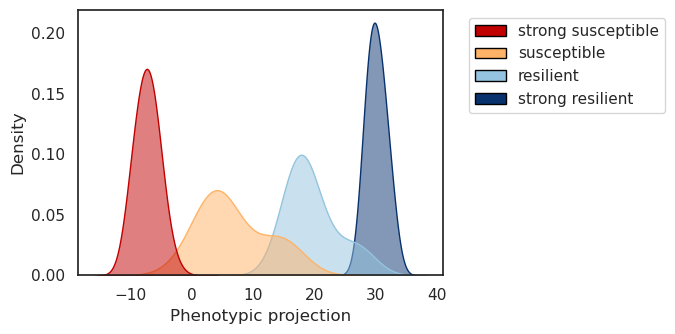

In [33]:
# this one uses LV8 instead of PP values - why??
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
sns.set(style="white")
cmap1 = cm.get_cmap('gist_heat')
cmap2 = cm.get_cmap('Blues')
custom_palette = [cmap1(0.5), cmap1(0.85), cmap2(0.4), cmap2(0.99)]
temp = df.copy()
bin_order = ['3', '2', '1', '0']
temp["14-6-Bin"] = temp["14-6-Bin"].astype(str)
plt.figure(figsize=(7, 3.5))
ax = sns.kdeplot(data=temp,x='LV8',hue="14-6-Bin",hue_order=bin_order,palette=custom_palette,fill=True,
    alpha=0.5,bw_adjust=5,common_norm=False,legend=False)
legend_labels = ['strong susceptible','susceptible','resilient','strong resilient']
legend_patches = [Patch(facecolor=custom_palette[i], edgecolor='black', label=legend_labels[i])
    for i in range(len(bin_order))]
ax.legend(handles=legend_patches,title="",bbox_to_anchor=(1.05, 1),loc='upper left')
plt.xlabel('Phenotypic projection')
plt.tight_layout()
plt.show()

/tmp/ipykernel_10410/2116143198.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = cm.get_cmap('gist_heat')
/tmp/ipykernel_10410/2116143198.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('Blues')


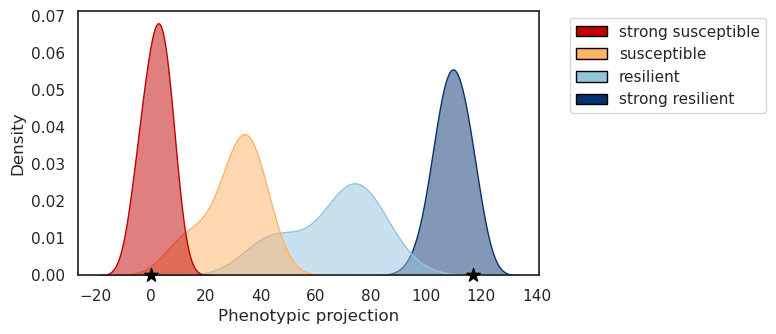

In [34]:
# this one uses PP axis (not one of the LVs)
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
sns.set(style="white")
cmap1 = cm.get_cmap('gist_heat')
cmap2 = cm.get_cmap('Blues')
custom_palette = [cmap1(0.5), cmap1(0.85), cmap2(0.4), cmap2(0.99)]
temp = df.copy()
bin_order = ['0', '1', '2', '3']
temp["14-6-Bin"] = temp["14-6-Bin"].astype(str)
plt.figure(figsize=(8, 3.5))
ax = sns.kdeplot(data=temp,x='PP',hue="14-6-Bin",hue_order=bin_order,palette=custom_palette,fill=True,
    alpha=0.5,bw_adjust=5,common_norm=False,legend=False)
legend_labels = ['strong susceptible','susceptible','resilient','strong resilient']
legend_patches = [Patch(facecolor=custom_palette[i], edgecolor='black', label=legend_labels[i])
    for i in range(len(bin_order))]
ax.legend(handles=legend_patches,title="",bbox_to_anchor=(1.05, 1),loc='upper left')
plt.xlabel('Phenotypic projection')
plt.tight_layout()
plt.savefig('kde.jpg')

# plot start and end points of trajectory to make sure they're reasonable
plt.scatter(df.loc[18260, 'PP'],0,color='black',marker='*',s=100,zorder=10, clip_on=False)
plt.scatter(df.loc[46470, 'PP'],0,color='black',marker='*',s=100,zorder=10, clip_on=False)

plt.show()




# how to also plot where my start and end points are?
# start point has index = 18260
# end point has index = 46470


In [35]:
df[df['Strain']=='66']['14-6-Bin'].unique()

array([], dtype=int64)

In [36]:
strain_order

<StringArray>
['83', '65', '161', '50', 'D2', '28', '39', '113', '33', 'B6', '99', '53',
 '124']
Length: 13, dtype: str

/tmp/ipykernel_10410/354705412.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = cm.get_cmap('gist_heat')
/tmp/ipykernel_10410/354705412.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('Blues')
/tmp/ipykernel_10410/354705412.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap3 = cm.get_cmap('viridis')


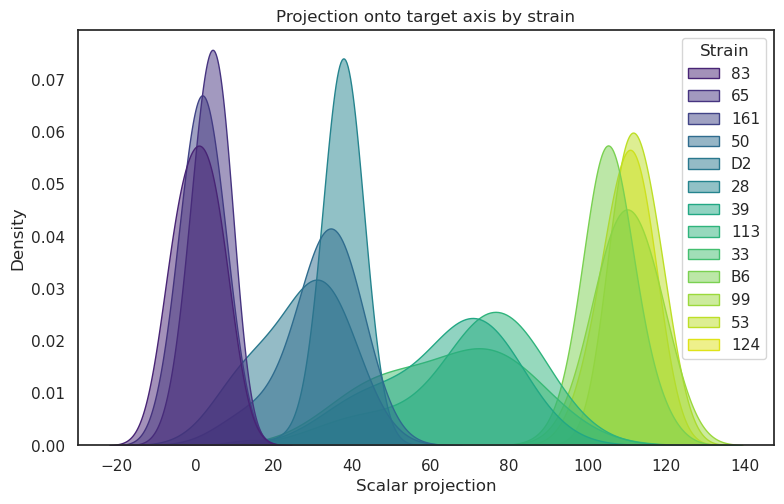

In [37]:
# this one uses PP axis (not one of the LVs)
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
sns.set(style="white")
cmap1 = cm.get_cmap('gist_heat')
cmap2 = cm.get_cmap('Blues')
cmap3 = cm.get_cmap('viridis')
custom_palette = [cmap3(0.1), cmap3(0.15), cmap3(0.2), cmap3(0.35), cmap3(0.4), cmap3(0.45), cmap3(0.6), cmap3(0.65), cmap3(0.7), cmap3(0.8), cmap3(0.85), cmap3(0.9), cmap3(0.95)]
temp = df.copy()
bin_order = ['0', '1', '2', '3']
temp["Strain"] = temp["Strain"].astype(str)
plt.figure(figsize=(8, 5))
# ax = sns.kdeplot(data=temp,x='PP',hue="14-6-Bin",hue_order=bin_order,palette=custom_palette,fill=True,
#     alpha=0.5,bw_adjust=5,common_norm=False,legend=False)
ax = sns.kdeplot(data=temp,x='PP',hue="Strain",hue_order = strain_order, palette=custom_palette, fill=True,
    alpha=0.5,bw_adjust=5,common_norm=False,legend=True)
# legend_labels = ['strong susceptible','susceptible','resilient','strong resilient']
# legend_patches = [Patch(facecolor=custom_palette[i], edgecolor='black', label=legend_labels[i])
    # for i in range(len(bin_order))]
# ax.legend(handles=legend_patches,title="",bbox_to_anchor=(1.05, 1),loc='upper left')
plt.xlabel('Scalar projection')
plt.tight_layout()
plt.savefig('kde.jpg')
plt.title('Projection onto target axis by strain')

# plot start and end points of trajectory to make sure they're reasonable
# plt.scatter(df.loc[18260, 'PP'],0,color='black',marker='*',s=100,zorder=10, clip_on=False)
# plt.scatter(df.loc[46470, 'PP'],0,color='black',marker='*',s=100,zorder=10, clip_on=False)

plt.show()

In [38]:
print(df.loc[18260, 'PP'])
print(df.loc[46470,'PP'])

-0.0
117.11850120110823


In [39]:
df_ordered = df.loc[:, ['PP']]
df_ordered = df_ordered.reset_index(names=['orig_index'])
df_ordered = df_ordered.sort_values(by='PP', ignore_index=True) # instead of adding index column, can ignore_index=False
df_ordered

start_index = 18260
end_index = 46470

print(df_ordered.loc[df_ordered['orig_index']==start_index])
print(df_ordered.loc[df_ordered['orig_index']==end_index])

      orig_index   PP
3780       18260 -0.0
       orig_index          PP
55295       46470  117.118501


In [40]:
print(df_ordered.index[df_ordered['orig_index']==start_index])
start_index_ordered = df_ordered.index[df_ordered['orig_index']==start_index][0] # grabs start index, which is what I want
end_index_ordered = df_ordered.index[df_ordered['orig_index']==end_index][0]
print(start_index_ordered)
print(end_index_ordered)

RangeIndex(start=3780, stop=3781, step=1)
3780
55295


In [41]:
print(df_ordered.loc[3776,'orig_index'])

31834


In [42]:
df_local = df_ordered.loc[start_index_ordered-250:start_index_ordered+250,:]
df_local
# df_ordered.loc[end_index_ordered-250:end_index_ordered+250,:]

,orig_index,PP
3530,54022,-0.303529
3531,54839,-0.303271
3532,11078,-0.303111
3533,54524,-0.301321
3534,42224,-0.301317
...,...,...
4026,1193,0.319508
4027,15170,0.319617
4028,48427,0.319718
4029,39399,0.323324


In [43]:
# check distance btwn our point and the extreme points
r_back = np.abs(df_ordered.loc[start_index_ordered,'PP']-df_ordered.loc[start_index_ordered-250,'PP'])
r_forward = np.abs(df_ordered.loc[start_index_ordered,'PP']-df_ordered.loc[start_index_ordered+250,'PP'])

print(r_back, r_forward)

# try radius between the two and see how many points that gets me
r_avg = (r_back + r_forward)/2
print(r_avg)

pp_back = df_ordered.loc[start_index_ordered,'PP'] - r_avg
pp_forward = df_ordered.loc[start_index_ordered,'PP'] + r_avg

print(pp_back, pp_forward)

# find all points within this radius
filtered_df = df_ordered[df_ordered['PP'].between(pp_back, pp_forward)]
print(filtered_df)

# number of points within this radius
num_points = len(filtered_df)-1
print(num_points)

pp_next = df_ordered.loc[start_index_ordered,'PP'] + 2*r_avg
print(pp_next)

0.303529151429237 0.3235963288012057
0.31356274011522134
-0.31356274011522134 0.31356274011522134
      orig_index        PP
3525       41805 -0.310081
3526        5631 -0.307846
3527       42813 -0.307480
3528       13886 -0.306903
3529       27563 -0.306458
...          ...       ...
4020       56044  0.307522
4021       50184  0.308080
4022       20259  0.309754
4023        8983  0.312085
4024       48253  0.312445

[500 rows x 2 columns]
499
0.6271254802304427


In [44]:
# find differences btwn PP values and desired next PP value
col_diffs = (df_ordered['PP'] - pp_next).abs()

# find index whose value is closest (min abs value from next PP value)
index_next = col_diffs.idxmin()
print(index_next)

4261


In [45]:
# kde plot along trajectory
# here can grab the data frame slice I find in the for loop below and use this to plot cfm?
# save original indices of neighbors?

# cfm_neighbors_transpose = cfm_neighbors.T

# print(cfm_neighbors_transpose.shape)

# column_names = []

# for i in range(len(path_example)):
#     column_names.append('point' + str(i))

# print(column_names)
# df_cfm_neighbors = pd.DataFrame(cfm_neighbors_transpose, columns=column_names)
# print(df_cfm_neighbors)

# plt.figure(figsize=(15,7))
# # plt.xlim(17,63)
# # plt.ylim(0,0.3)
# plt.xlabel('Decoded CFM of 20 NNs')

# colors_husl = sns.color_palette("husl", 31)

# for i in range(len(path_example)):
#     x_name = 'point'+str(i)
#     sns.kdeplot(data=df_cfm_neighbors, x=x_name, alpha=0.5, common_norm=False, fill=True, bw_adjust=1, label = x_name)

# sns.color_palette("husl", 8)
# plt.legend()

In [46]:
df_latent

,z_1,z_2,z_3,z_4,z_5,z_6,z_7,z_8,z_9,z_10,label,decoded_cfm
0,-24.256855,-18.943563,-19.148005,-13.069660,-7.281853,-6.647669,-1.973320,1.312754,5.479063,10.920240,2,1.048495
1,-32.498856,-27.973068,-25.985146,-23.571732,-19.487030,-15.888780,-14.033054,-9.226448,-8.665678,-4.734122,3,1.236806
2,-17.562922,-16.157148,-7.969545,-5.897250,1.853780,4.455924,9.762284,14.726957,23.734491,29.096786,2,1.044764
3,-28.858011,-24.174309,-22.691444,-19.941648,-16.066748,-12.556651,-10.494271,-5.782712,-5.136093,-1.035175,3,-0.825561
4,-10.571421,-6.463661,0.640753,7.082870,11.920109,17.315226,24.198599,28.219280,36.607440,41.267610,0,0.690024
...,...,...,...,...,...,...,...,...,...,...,...,...
56645,-28.579952,-23.901604,-22.118683,-19.591473,-15.684873,-12.046993,-10.108648,-5.416104,-4.710186,-0.721344,3,0.267969
56646,-7.582398,-3.366018,3.963249,10.430345,15.107400,20.847500,27.655052,31.937830,40.201540,44.993100,0,-0.972245
56647,-17.119564,-13.705447,-7.196110,-4.540887,3.223161,5.727212,10.905486,15.751303,24.399230,29.637558,2,0.547159
56648,-29.270935,-24.531736,-22.611712,-20.303423,-16.054407,-12.572237,-10.648892,-5.845601,-5.259646,-1.332067,3,1.229240


In [47]:
print(df_latent.loc[18260,:])
print(df_latent.loc[46470,:])

z_1            -8.407204
z_2            -4.246681
z_3             2.881962
z_4             9.409945
z_5            14.161424
z_6            19.746548
z_7            26.679409
z_8            30.815266
z_9            39.042070
z_10           44.011818
label           0.000000
decoded_cfm    -1.623062
Name: 18260, dtype: float64
z_1           -32.783695
z_2           -28.245910
z_3           -26.353554
z_4           -24.086870
z_5           -19.939394
z_6           -16.430355
z_7           -14.561339
z_8            -9.774122
z_9            -9.151783
z_10           -5.255166
label           3.000000
decoded_cfm     1.249484
Name: 46470, dtype: float64


In [48]:
print(df_ordered.loc[df_ordered['orig_index']==18260])

      orig_index   PP
3780       18260 -0.0


In [49]:
# create a loop
# stop the loop when pp_next > final pp value in df
# eventually need to add last pp value as final point of trajectory
start_index = 18260
end_index = 46470
density_req = 1000 # number of points we want within radius for each step

start_index_ordered = df_ordered.index[df_ordered['orig_index']==start_index][0] # grabs start index, which is what I want
end_index_ordered = df_ordered.index[df_ordered['orig_index']==end_index][0]
print(start_index_ordered)
print(end_index_ordered)

pp_next = 0 # could probably initialize this better but this is safe
pp_final = df_ordered.loc[end_index_ordered,'PP']
print(pp_final)

cur_point_index = start_index_ordered

num_steps = 0

traj_info = []

while pp_next < pp_final:
    pp_current = df_ordered.loc[cur_point_index,'PP']
    pp_proposed_back = df_ordered.loc[cur_point_index-(density_req/2),'PP']
    pp_proposed_forward = df_ordered.loc[cur_point_index+(density_req/2),'PP']

    print('actual next pp value = ', pp_current)

    # find original index for the current point
    # find row of df for current index, then grab orig_index column value
    cur_point_orig_index = df_ordered.loc[cur_point_index,'orig_index']

    # get decoded CFM of point using original index
    cur_point_cfm = df_latent.loc[cur_point_orig_index,'decoded_cfm']
    
    # check distance btwn our point and the extreme points
    r_back = np.abs(pp_current-pp_proposed_back)
    r_forward = np.abs(pp_current-pp_proposed_forward)
    print('backward distance = ', r_back, 'forward distance = ', r_forward)

    # try radius between the two (average) and see how many points that gets me
    r_avg = (r_back + r_forward)/2
    print('radius for this step = ', r_avg)

    pp_back = df_ordered.loc[cur_point_index,'PP'] - r_avg
    pp_forward = df_ordered.loc[cur_point_index,'PP'] + r_avg
    print(pp_back, pp_forward)

    # find all points within this radius
    filtered_df = df_ordered[df_ordered['PP'].between(pp_back, pp_forward)]

    # number of points within this radius
    num_points = len(filtered_df)-1
    print('# of points within radius = ', num_points)

    # should add condition for if number of points is way too far off
    # how far off is too far off?? more than 10%?
    # or should condition instead/also have to do with cfm/label dist?

    # below is what I tried but it's flawed (what if I overcorrect in one of the loops)

    # if too few points w/in radius, increase radius
    if num_points < 0.9*density_req:
        # find which radius is bigger (back or forward)
        r_max = max(r_back, r_forward)
        r_min = min(r_back, r_forward)

        # weight average more heavily toward r_max
        for i in range(4):
            weight_adj = 0.1*(i+1)
            r_avg = (0.5+weight_adj)*r_max + (0.5-weight_adj)*r_min

            print('adjusted radius for this step = ', r_avg)

            pp_back = df_ordered.loc[cur_point_index,'PP'] - r_avg
            pp_forward = df_ordered.loc[cur_point_index,'PP'] + r_avg
            print(pp_back, pp_forward)

            # find all points within this radius
            filtered_df = df_ordered[df_ordered['PP'].between(pp_back, pp_forward)]

            # number of points within this radius
            num_points = len(filtered_df)-1
            print('new # of points within radius = ', num_points)
            if num_points >= 0.9*density_req:
                break
    
    # if too many points w/in radius: decrease radius
    if num_points > 1.1*density_req:
        # find which radius is smaller (back or forward)
        r_max = max(r_back, r_forward)
        r_min = min(r_back, r_forward)

        # weight average more heavily toward r_min
        for i in range(4):
            weight_adj = 0.1*(i+1)
            r_avg = (0.5-weight_adj)*r_max + (0.5+weight_adj)*r_min

            print('adjusted radius for this step = ', r_avg)

            pp_back = df_ordered.loc[cur_point_index,'PP'] - r_avg
            pp_forward = df_ordered.loc[cur_point_index,'PP'] + r_avg
            print(pp_back, pp_forward)

            # find all points within this radius
            filtered_df = df_ordered[df_ordered['PP'].between(pp_back, pp_forward)]
            print(filtered_df)

            # number of points within this radius
            num_points = len(filtered_df)-1
            print('new # of points within radius = ', num_points)
            if num_points <= 1.1*density_req:
                break
    
    # print('final filtered df = ', filtered_df)

    # use filtered_df to get original indices of neighbors
    # get bins and decoded CFM from original indices

    cfm_neighbor_all = []
    bin_neighbor_all = []

    for i in range(len(filtered_df)):
        # for now I'll include the trajectory point, but I could exclude it
        neighbor_orig_index = filtered_df.iloc[i,0] 
        cfm_neighbor = df_latent.loc[neighbor_orig_index,'decoded_cfm']
        bin_neighbor = df_latent.loc[neighbor_orig_index,'label']
        
        cfm_neighbor_all.append(float(cfm_neighbor))
        bin_neighbor_all.append(int(bin_neighbor))

    pp_next = df_ordered.loc[cur_point_index,'PP'] + 2*r_avg
    print('proposed next PP value = ', pp_next)

    # find differences btwn PP values and desired next PP value
    col_diffs = (df_ordered['PP'] - pp_next).abs()

    # find index whose value is closest (min abs value from next PP value)
    index_next = col_diffs.idxmin()
    print(index_next)

    # fix how this is structured
    new_dict = {'original index': int(cur_point_orig_index), 'local density': int(num_points), 'radius': float(r_avg), 'PP value': float(pp_current),
        'decoded CFM': float(cur_point_cfm), 'neighbor CFM': cfm_neighbor_all, 'neighbor bins': bin_neighbor_all}
    traj_info.append((new_dict))

    # check how I'm doing this because it might not be counting final step to get to endpoint
    num_steps += 1

    # update index for next point
    cur_point_index = index_next

# dictionary entry for last point - don't have anything for radius or density?
last_dict = {'original index': int(end_index), 'local density': int(0), 'radius': float(0), 'PP value': float(pp_final),
    'decoded CFM': float(df_latent.loc[end_index,'decoded_cfm'])}
traj_info.append((last_dict))

print('total # steps = ', num_steps)

3780
55295
117.11850120110823
actual next pp value =  -0.0
backward distance =  0.6773348623977491 forward distance =  0.6524363240667101
radius for this step =  0.6648855932322296
-0.6648855932322296 0.6648855932322296
# of points within radius =  1001
proposed next PP value =  1.3297711864644592
4857
actual next pp value =  1.32945633036675
backward distance =  0.5887098722840101 forward distance =  0.5579168707280642
radius for this step =  0.5733133715060371
0.7561429588607128 1.9027697018727872
# of points within radius =  998
proposed next PP value =  2.476083073378824
5888
actual next pp value =  2.4764196064031023
backward distance =  0.5468225583475386 forward distance =  0.5338114537923775
radius for this step =  0.540317006069958
1.9361026003331443 3.0167366124730606
# of points within radius =  1007
proposed next PP value =  3.5570536185430184
6897
actual next pp value =  3.558525247112754
backward distance =  0.5421745778468048 forward distance =  0.5335152353361345
radius

In [50]:
traj_info

[{'original index': 18260,
  'local density': 1001,
  'radius': 0.6648855932322296,
  'PP value': -0.0,
  'decoded CFM': -1.623062014579773,
  'neighbor CFM': [-0.982511818408966,
   0.7123938798904419,
   0.7045811414718628,
   -0.9825109243392944,
   -0.983323574066162,
   -1.623048186302185,
   -0.9779388308525084,
   -1.6153411865234375,
   -1.6006072759628296,
   -1.623032569885254,
   -1.6230573654174805,
   -1.622603178024292,
   -0.9797949194908142,
   -1.623062014579773,
   0.6952036619186401,
   -0.9709537029266356,
   -0.9832630157470704,
   -0.983572781085968,
   -0.9837424159049988,
   -0.98061203956604,
   -1.5414988994598389,
   -1.6230508089065552,
   -1.5109249353408811,
   -1.4539791345596311,
   -1.4799046516418457,
   0.7133053541183472,
   -1.6230459213256836,
   0.7026370763778687,
   0.7120283842086792,
   -1.623060703277588,
   0.7128888368606567,
   0.7199410200119019,
   -0.982974112033844,
   0.7175461053848267,
   -1.623062014579773,
   -0.9835115671157836,


In [51]:
# df_cfm_neighbors_reshaped = pd.DataFrame(traj_info[0], columns=['original_index', 'local_density', 'radius'])

df_list=[]

for traj_index in range(len(traj_info)-1):

    df_traj_new = pd.DataFrame({
        'traj_point': pd.Series(dtype='str'),
        'orig_index': pd.Series(dtype='int'),
        'local_density': pd.Series(dtype='int'),
        'radius': pd.Series(dtype='float'),
        'pp_value': pd.Series(dtype='float'),
        'decoded_cfm': pd.Series(dtype='float'),
        'neighbor_cfm': pd.Series(dtype='float'),
        'neighbor_bins': pd.Series(dtype='int')
    })

    df_traj_new['neighbor_cfm'] = traj_info[traj_index]['neighbor CFM']
    df_traj_new['neighbor_bins'] = traj_info[traj_index]['neighbor bins']
    df_traj_new['decoded_cfm'] = traj_info[traj_index]['decoded CFM']
    df_traj_new['pp_value'] = traj_info[traj_index]['PP value']
    df_traj_new['radius'] = traj_info[traj_index]['radius']
    df_traj_new['local_density'] = traj_info[traj_index]['local density']
    df_traj_new['orig_index'] = traj_info[traj_index]['original index']
    df_traj_new['traj_point'] = 'point_' + str(traj_index)

    print(df_traj_new)

    df_list.append(df_traj_new)

     traj_point  orig_index  local_density    radius  pp_value  decoded_cfm  \
0       point_0       18260           1001  0.664886      -0.0    -1.623062   
1       point_0       18260           1001  0.664886      -0.0    -1.623062   
2       point_0       18260           1001  0.664886      -0.0    -1.623062   
3       point_0       18260           1001  0.664886      -0.0    -1.623062   
4       point_0       18260           1001  0.664886      -0.0    -1.623062   
...         ...         ...            ...       ...       ...          ...   
997     point_0       18260           1001  0.664886      -0.0    -1.623062   
998     point_0       18260           1001  0.664886      -0.0    -1.623062   
999     point_0       18260           1001  0.664886      -0.0    -1.623062   
1000    point_0       18260           1001  0.664886      -0.0    -1.623062   
1001    point_0       18260           1001  0.664886      -0.0    -1.623062   

      neighbor_cfm  neighbor_bins  
0        -0.982

In [52]:
df_traj_all = pd.concat(df_list, ignore_index=True)
df_traj_all

,traj_point,orig_index,local_density,radius,pp_value,decoded_cfm,neighbor_cfm,neighbor_bins
0,point_0,18260,1001,0.664886,-0.000000,-1.623062,-0.982512,0
1,point_0,18260,1001,0.664886,-0.000000,-1.623062,0.712394,0
2,point_0,18260,1001,0.664886,-0.000000,-1.623062,0.704581,0
3,point_0,18260,1001,0.664886,-0.000000,-1.623062,-0.982511,0
4,point_0,18260,1001,0.664886,-0.000000,-1.623062,-0.983324,0
...,...,...,...,...,...,...,...,...
51731,point_50,56201,1012,1.039369,116.921275,0.484047,1.231964,3
51732,point_50,56201,1012,1.039369,116.921275,0.484047,0.268422,3
51733,point_50,56201,1012,1.039369,116.921275,0.484047,0.782233,3
51734,point_50,56201,1012,1.039369,116.921275,0.484047,1.238448,3


In [53]:
df_latent.loc[56649,'decoded_cfm']

np.float64(0.5422126054763794)

In [54]:
df['CFM_14_5_snRNA']

0        1.047481
1        1.231932
2        1.047481
3       -0.825919
4        0.708210
           ...   
56645    0.263749
56646   -0.974072
56647    0.550426
56648    1.231932
56649    0.550426
Name: CFM_14_5_snRNA, Length: 56650, dtype: float64

41.66857142857143
12.840019684350391
[20.828423212445745, 50.802271520476324, 20.828430865693868, 50.64617587178108, 21.000725379364017, 29.069181345047248, 23.058357770985648, 29.118270809151042, 20.879672423169556, 24.309278115218678, 24.495025508437593, 24.621050014612074, 28.056510441474487, 27.8222705375053, 24.563442485348553, 24.612772261443375, 38.751015486018936, 28.021951434255026, 28.239263884028098, 28.265895656842847, 40.79339495413352, 55.08097294801339, 55.08647104146419, 55.06430723490303, 40.79771597802318, 40.826724849704604, 40.837148573646694, 40.75072809585367, 40.74284678093768, 55.04630373402097, 40.79755679046224, 40.65321040828381, 48.66845104380071, 48.690317904334734, 48.6502883553577, 48.717202234337506, 48.66622854054609, 48.44723237618619, 48.7728872676728, 48.68426877701915, 31.095548687441095, 57.4157524138751, 57.4795468289204, 45.7447066848168, 57.43109564570997, 57.39061302444412, 57.40022244278604, 31.079254156864657, 31.09137843253945, 57.3977366677

<Figure size 2000x700 with 0 Axes>

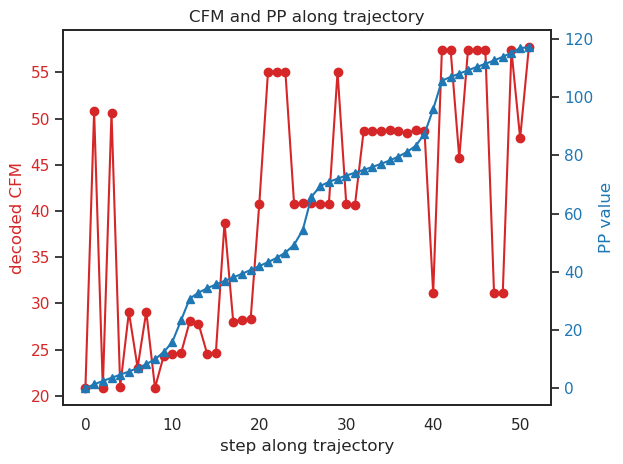

In [55]:
# plot trajectory: PP value, CFM
# CFM_CSV_PATH  = "/nfs/turbo/umms-kaczoro/u19-shared/vae-HC-PFC/14mon_ADBXD_joined/input_datasets/CFC_CFM_residual_Bins_all_Strains.csv"
CFM_CSV_PATH = '/home/nghayes/latent-space-trajectories/CFC_CFM_residual_Bins_all_Strains.csv'
df_cfm = pd.read_csv(CFM_CSV_PATH)
figsize=(20, 7)
plt.figure(figsize=figsize)
mean_cfm = df_cfm['CFM_14_5_snRNA'].mean()
print(mean_cfm)
std_cfm  = df_cfm['CFM_14_5_snRNA'].std()
print(std_cfm)

fig, ax1 = plt.subplots()

ax1.set_xlabel('step along trajectory')
ax1.set_ylabel('decoded CFM', color='tab:red')

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
ax2.set_ylabel('PP value', color='tab:blue')  # we already handled the x-label with ax1

plt.title('CFM and PP along trajectory')

all_cfm = []
all_pp = []

for i in range(len(traj_info)):
    descaled_cfm = traj_info[i]['decoded CFM'] * std_cfm + mean_cfm
    all_cfm.append(float(descaled_cfm))
    # print(traj_info[i])
    
    pp_value = traj_info[i]['PP value']
    all_pp.append(pp_value)

print(all_cfm)
print(all_pp)

ax1.plot(all_cfm, '-o',color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax2.plot(all_pp, '-^',color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()


[0.6648855932322296, 0.5733133715060371, 0.540317006069958, 0.5378449065914697, 0.5504274718586402, 0.5883689310923783, 0.6709619174147945, 0.8640163748671661, 1.1836674121253177, 1.7869751777598353, 3.696845604144836, 3.7288257503234363, 1.0208405114777417, 0.7510465147851093, 0.6689171362657476, 0.6150172845688644, 0.5766102940760511, 0.6234737706267417, 0.668867979451651, 0.6759913697592523, 0.653290046706239, 0.7562124128052332, 0.8928947403850174, 1.3501859711933442, 2.553191449766268, 5.681352399274369, 1.8499675452835254, 0.7050706266851776, 0.5828565122428842, 0.5089972509202738, 0.5049315385463657, 0.48261749511301133, 0.4964456391084937, 0.5365132964054808, 0.5838173039942021, 0.6662347987448456, 0.7945447349523818, 1.0694506263626806, 2.03952427012435, 4.22951861176888, 4.905538709309452, 0.6350596552989742, 0.5720453584926801, 0.5817683268673406, 0.5599279950352809, 0.5545733979666352, 0.5721489939057989, 0.6252532139162739, 0.6818550580686136, 0.8393687572507318, 1.0393685

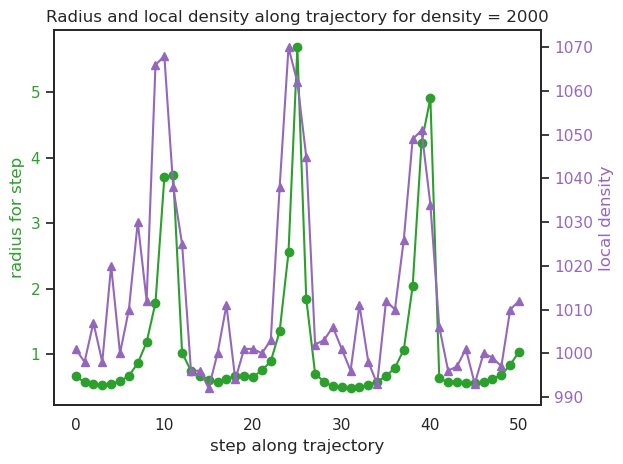

In [56]:
fig, ax1 = plt.subplots()

ax1.set_xlabel('step along trajectory')
ax1.set_ylabel('radius for step', color='tab:green')

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
ax2.set_ylabel('local density', color='tab:purple')  # we already handled the x-label with ax1

plt.title('Radius and local density along trajectory for density = 2000')

all_radius = []
all_density = []

for i in range(len(traj_info)-1):
    all_radius.append(float(traj_info[i]['radius']))
    # print(traj_info[i])
    
    all_density.append(traj_info[i]['local density'])

print(all_radius)
print(all_density)

ax1.plot(all_radius, '-o',color='tab:green')
ax1.tick_params(axis='y', labelcolor='tab:green')
ax2.plot(all_density, '-^',color='tab:purple')
ax2.tick_params(axis='y', labelcolor='tab:purple')

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

/tmp/ipykernel_10410/4069622458.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = cm.get_cmap('gist_heat')
/tmp/ipykernel_10410/4069622458.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('Blues')


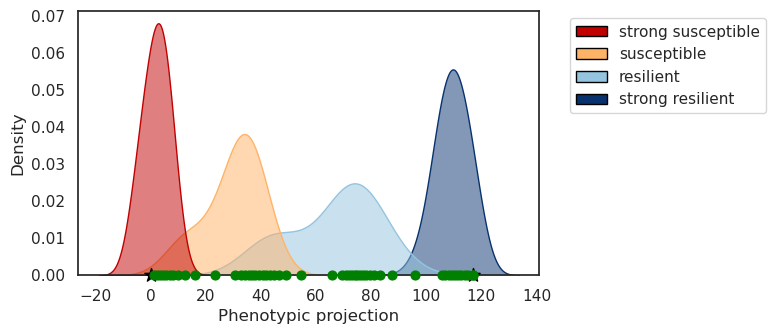

In [57]:
# this one uses PP axis (not one of the LVs)
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
sns.set(style="white")
cmap1 = cm.get_cmap('gist_heat')
cmap2 = cm.get_cmap('Blues')
custom_palette = [cmap1(0.5), cmap1(0.85), cmap2(0.4), cmap2(0.99)]
temp = df.copy()
bin_order = ['0', '1', '2', '3']
temp["14-6-Bin"] = temp["14-6-Bin"].astype(str)
plt.figure(figsize=(8, 3.5))
ax = sns.kdeplot(data=temp,x='PP',hue="14-6-Bin",hue_order=bin_order,palette=custom_palette,fill=True,
    alpha=0.5,bw_adjust=5,common_norm=False,legend=False)
legend_labels = ['strong susceptible','susceptible','resilient','strong resilient']
legend_patches = [Patch(facecolor=custom_palette[i], edgecolor='black', label=legend_labels[i])
    for i in range(len(bin_order))]
ax.legend(handles=legend_patches,title="",bbox_to_anchor=(1.05, 1),loc='upper left')
plt.xlabel('Phenotypic projection')
plt.tight_layout()
plt.savefig('kde.jpg')

# plot all trajectory points
plt.scatter(df.loc[18260, 'PP'],0,color='black',marker='*',s=100,zorder=10, clip_on=False)
plt.scatter(df.loc[46470, 'PP'],0,color='black',marker='*',s=100,zorder=10, clip_on=False)
for i in range(len(traj_info)-1): # minus 1 to exclude first point
    new_value = traj_info[i+1]['PP value']
    plt.scatter(new_value,0,color='green',marker='o',s=40,zorder=10, clip_on=False)


plt.show()

# how to also plot where my start and end points are?
# start point has index = 18260
# end point has index = 46470


In [58]:
print(np.max(df_list[5]['neighbor_cfm']) * std_cfm + mean_cfm)
print(np.min(df_list[5]['neighbor_cfm']) * std_cfm + mean_cfm)
print(np.median(df_list[5]['neighbor_cfm']) * std_cfm + mean_cfm)

51.407346500895216
20.828423212445745
29.10779198182247


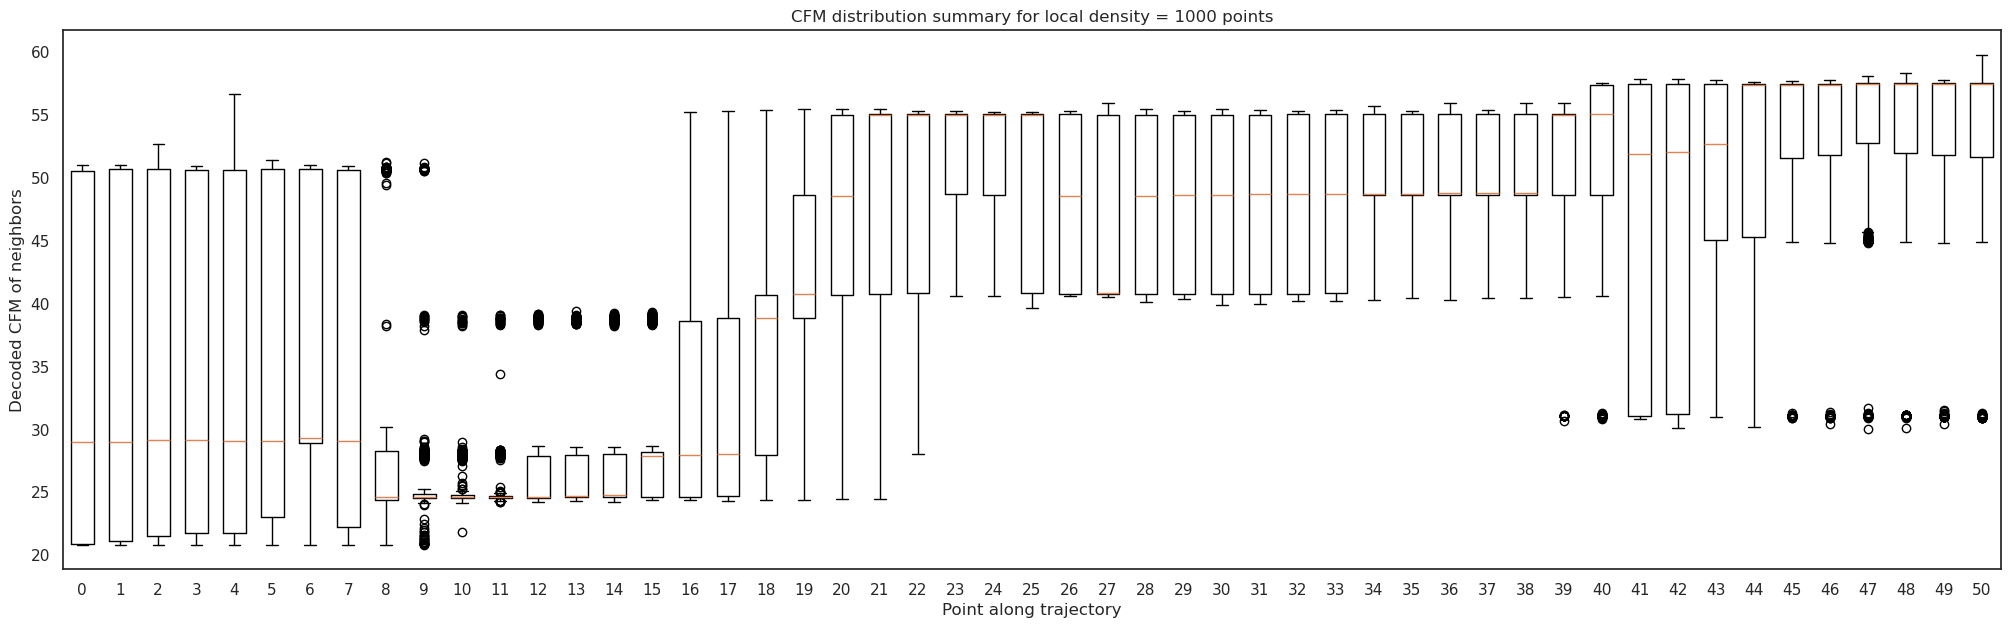

In [59]:
plt.figure(figsize=(25,7))
plt.xlabel('Point along trajectory')
plt.ylabel('Decoded CFM of neighbors')
plt.title('CFM distribution summary for local density = ' + str(density_req) + ' points')

for i in range(len(traj_info)-1):
    df_traj = df_list[i]
    neighbors_cfm = df_traj['neighbor_cfm'] * std_cfm + mean_cfm
    # print(new_neighbors)
    plt.boxplot(neighbors_cfm, positions=[i], widths=[0.6])

In [60]:
df_traj_all['neighbor_cfm'] = df_traj_all['neighbor_cfm'] * std_cfm + mean_cfm
df_traj_all

,traj_point,orig_index,local_density,radius,pp_value,decoded_cfm,neighbor_cfm,neighbor_bins
0,point_0,18260,1001,0.664886,-0.000000,-1.623062,29.053100,0
1,point_0,18260,1001,0.664886,-0.000000,-1.623062,50.815723,0
2,point_0,18260,1001,0.664886,-0.000000,-1.623062,50.715407,0
3,point_0,18260,1001,0.664886,-0.000000,-1.623062,29.053112,0
4,point_0,18260,1001,0.664886,-0.000000,-1.623062,29.042677,0
...,...,...,...,...,...,...,...,...
51731,point_50,56201,1012,1.039369,116.921275,0.484047,57.487019,3
51732,point_50,56201,1012,1.039369,116.921275,0.484047,45.115117,3
51733,point_50,56201,1012,1.039369,116.921275,0.484047,51.712463,3
51734,point_50,56201,1012,1.039369,116.921275,0.484047,57.570268,3


Text(0.5, 0, 'Local CFM distribution')

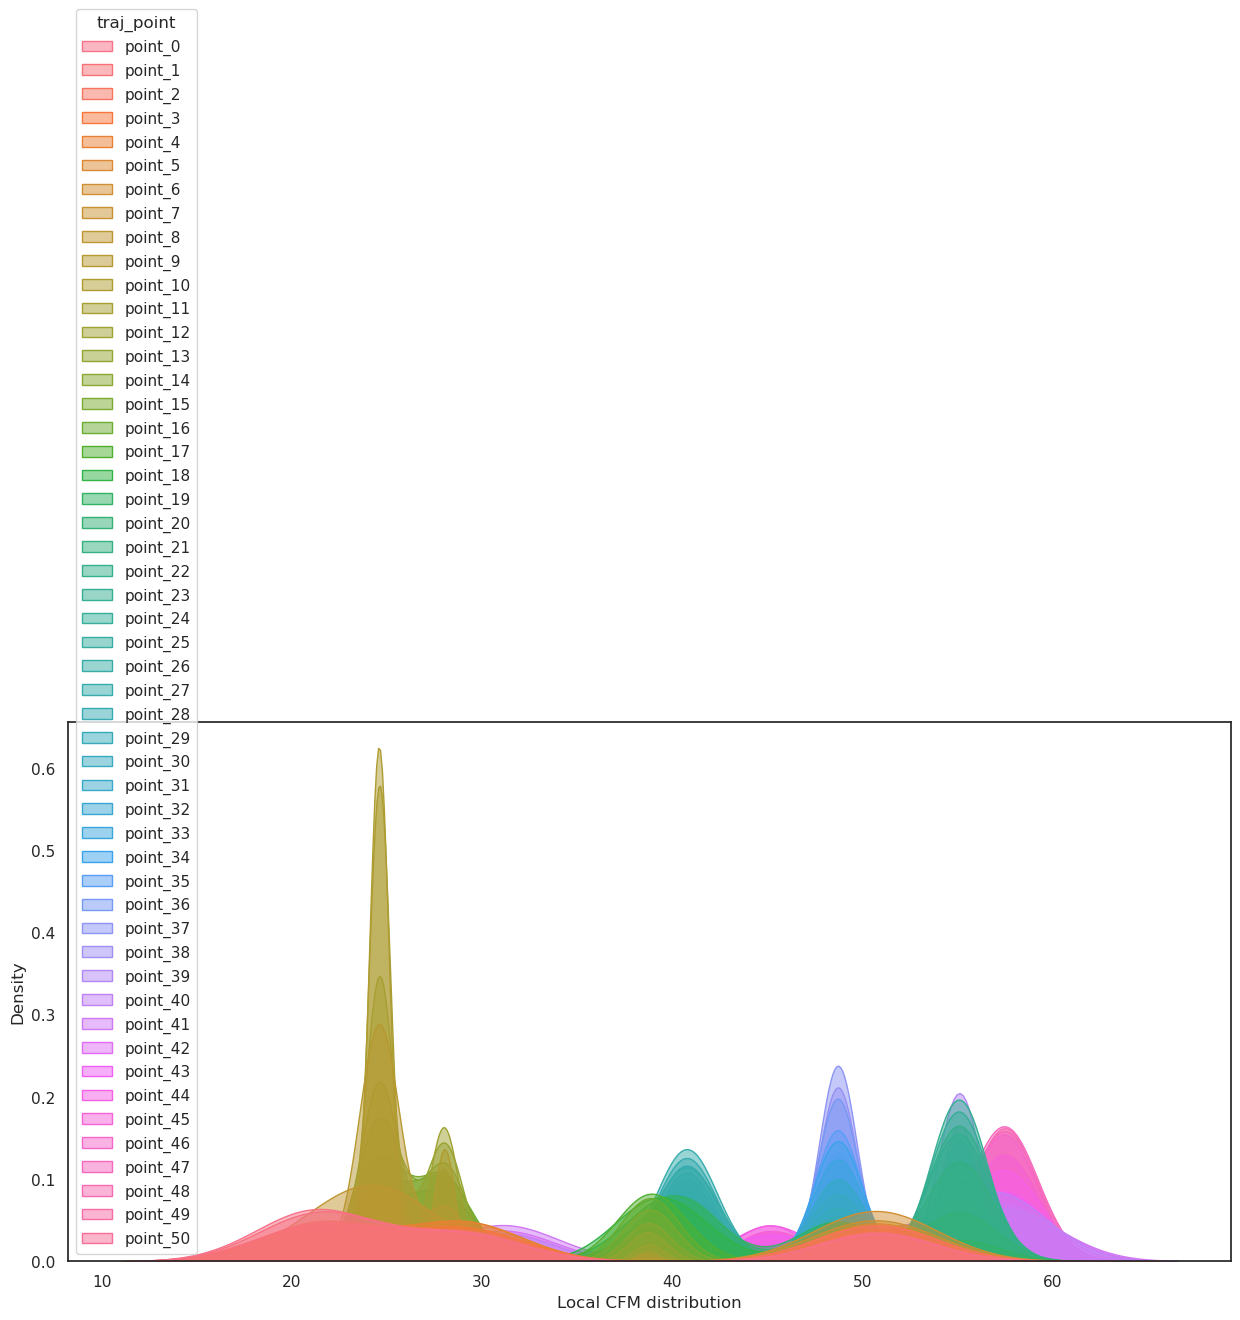

In [61]:
plt.figure(figsize=(15,7))
# plt.xlim(17,63)
# plt.ylim(0,0.3)
sns.kdeplot(data=df_traj_all, x='neighbor_cfm', hue='traj_point', alpha=0.5, common_norm=False, fill=True, bw_adjust=1)
plt.xlabel('Local CFM distribution')

9.257410341415364
62.57188924157048
9.158747661946336
62.68620434409851
8.653458055747409
64.84077504317558
8.877404440399012
62.93839481289972
9.158317693819658
68.33782946106204
9.097893624136114
63.137876089204845
8.67628345305737
63.20115506061553
8.524253062123941
63.23839285231824
10.599106295022333
61.470489972496416
15.873401048052843
56.191653782030336
19.360235174604615
41.58668436763998
21.618652501164913
41.667912442097325
21.003118440047974
42.35202572898541
20.243867134032964
43.45570228283091
19.568406170231757
43.89475288149554
19.064640986781566
44.60952883021519
17.81818585718912
61.79813297166753
16.878162567206488
62.75308162613758
15.58297383978221
64.18590942908621
15.865112047888987
64.01077740557088
16.33516794887064
63.611217103690095
17.178250034372095
62.838736232113604
21.36971867052637
61.9431373690263
35.04320353404076
60.87621138655194
34.91816766783097
60.98402744448734
33.62140462947256
61.29113366170051
34.393281639778834
61.5409530304772
34.5403288071

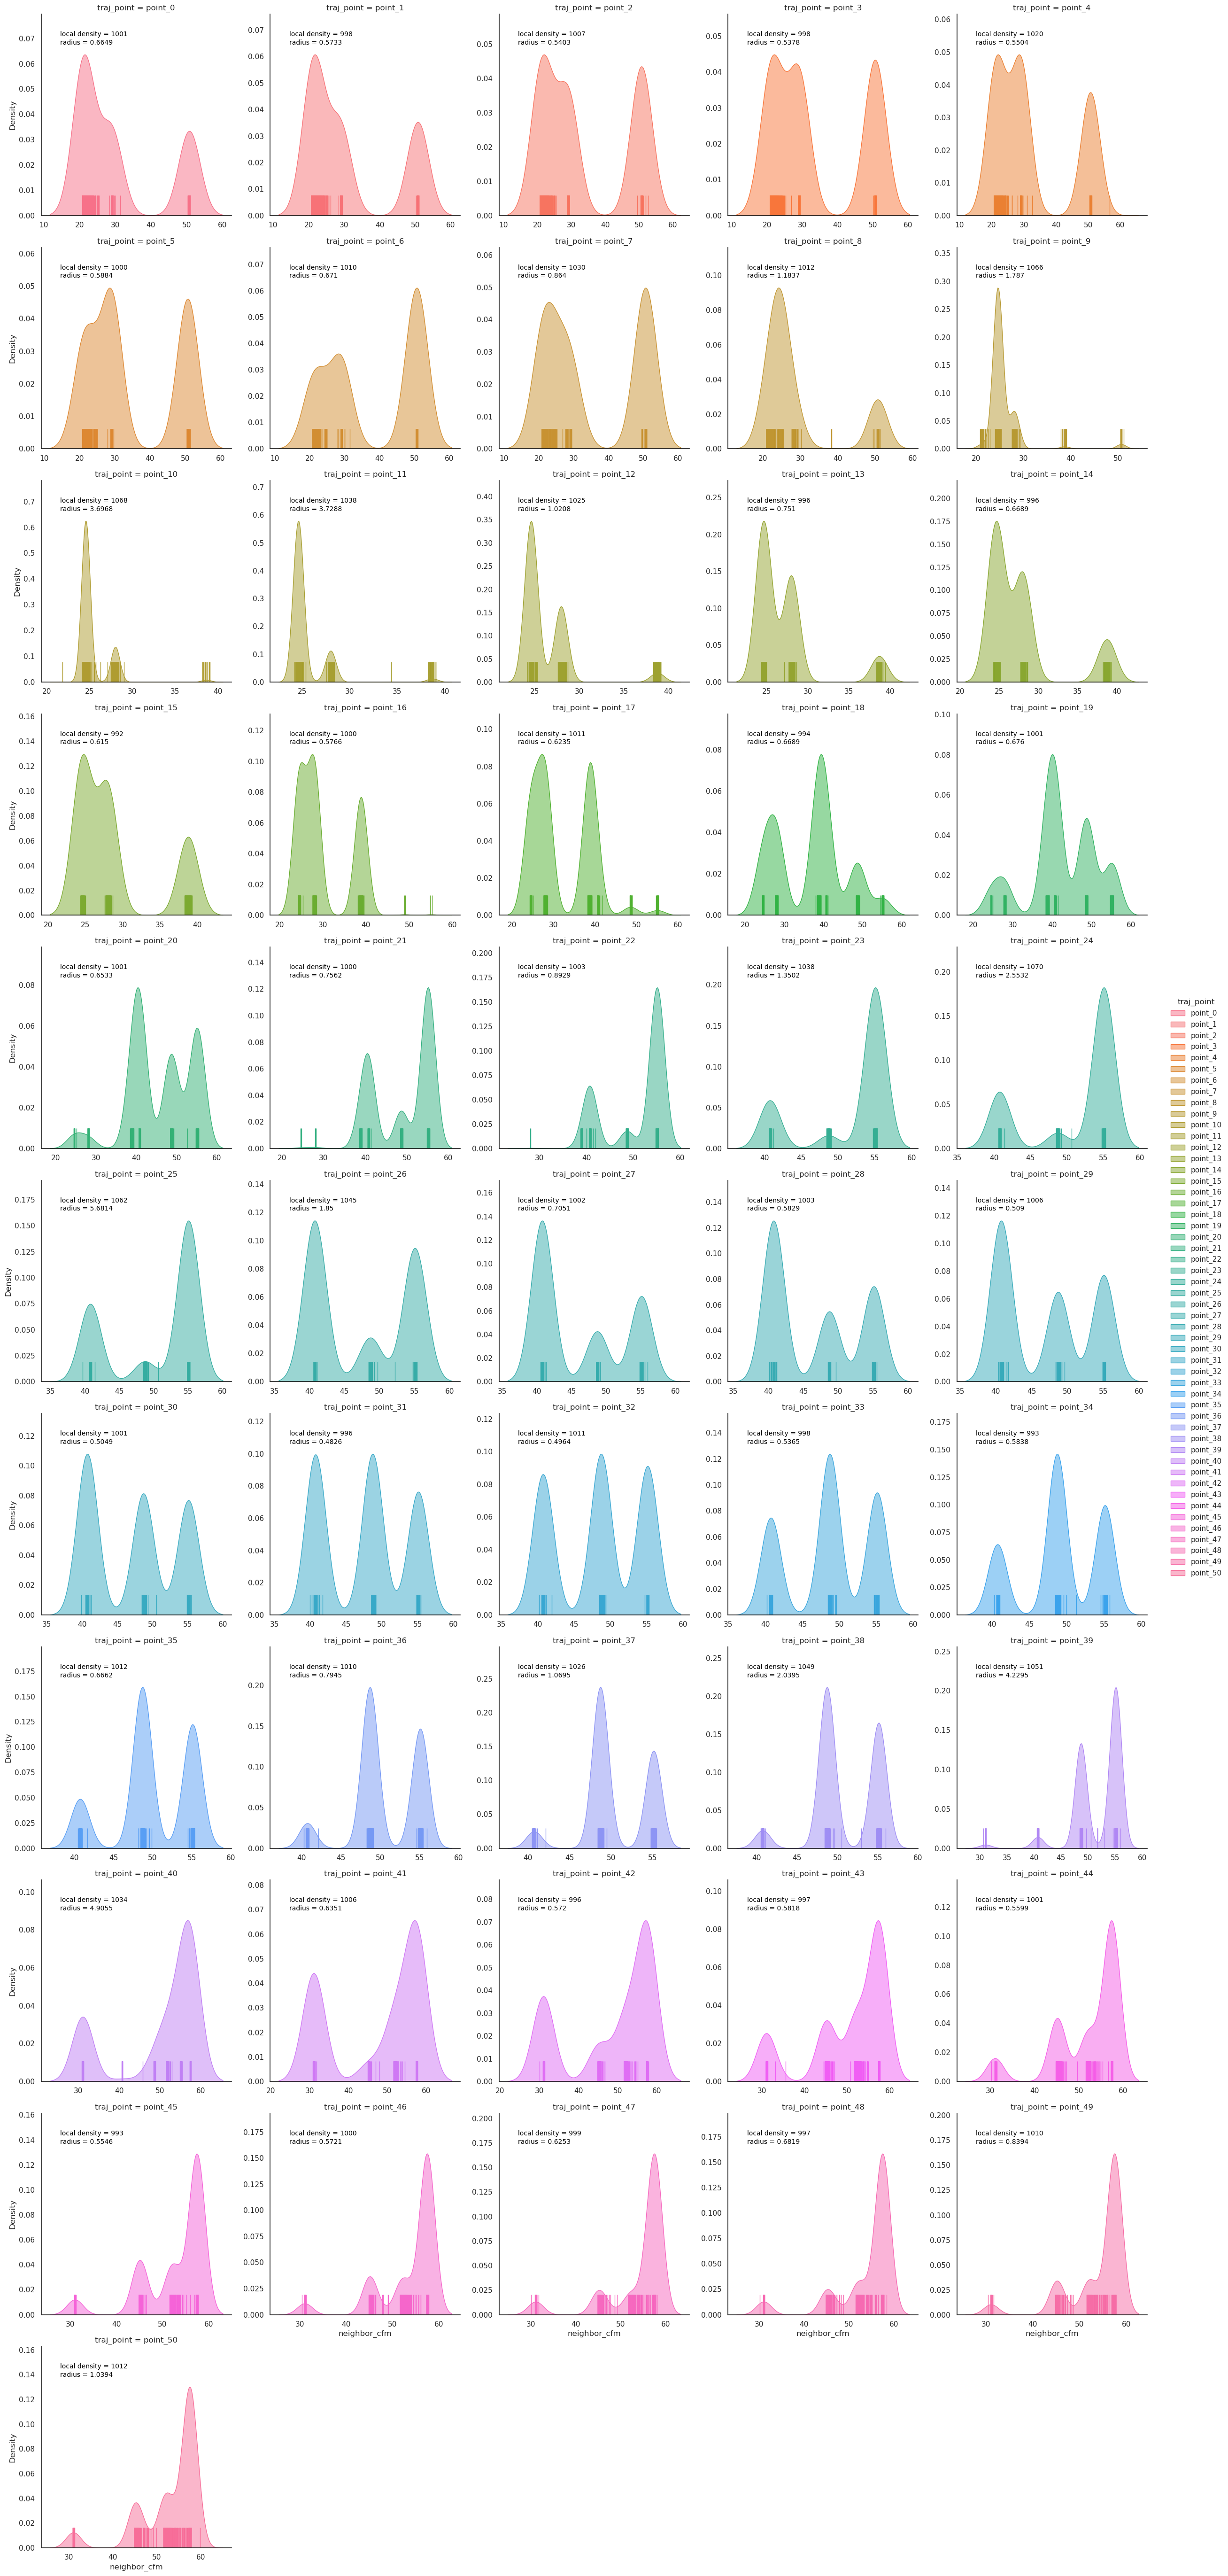

In [62]:
g = sns.displot(data=df_traj_all, x='neighbor_cfm', hue='traj_point', col='traj_point', col_wrap=5, fill=True, kind='kde', alpha=0.5, common_norm=False, bw_adjust=1, rug=True, rug_kws={'height':0.1}, facet_kws={'sharex': False, 'sharey': False})

for i in range(len(traj_info)-1):
    ax = g.axes.flat[i]
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    df_traj = df_list[i]
    density_value = df_traj.loc[0,'local_density']
    radius_step = round(df_traj.loc[0, 'radius'],4)
    print(xmin)
    print(xmax)
    ax.text(x=xmin+(xmax-xmin)/10, y=ymax-(ymax-ymin)/12, s='local density = ' + str(density_value), horizontalalignment='left', verticalalignment='top', fontsize=10, color='black')
    ax.text(x=xmin+(xmax-xmin)/10, y=ymax-(ymax-ymin)/8, s='radius = ' + str(radius_step), horizontalalignment='left', verticalalignment='top', fontsize=10, color='black')

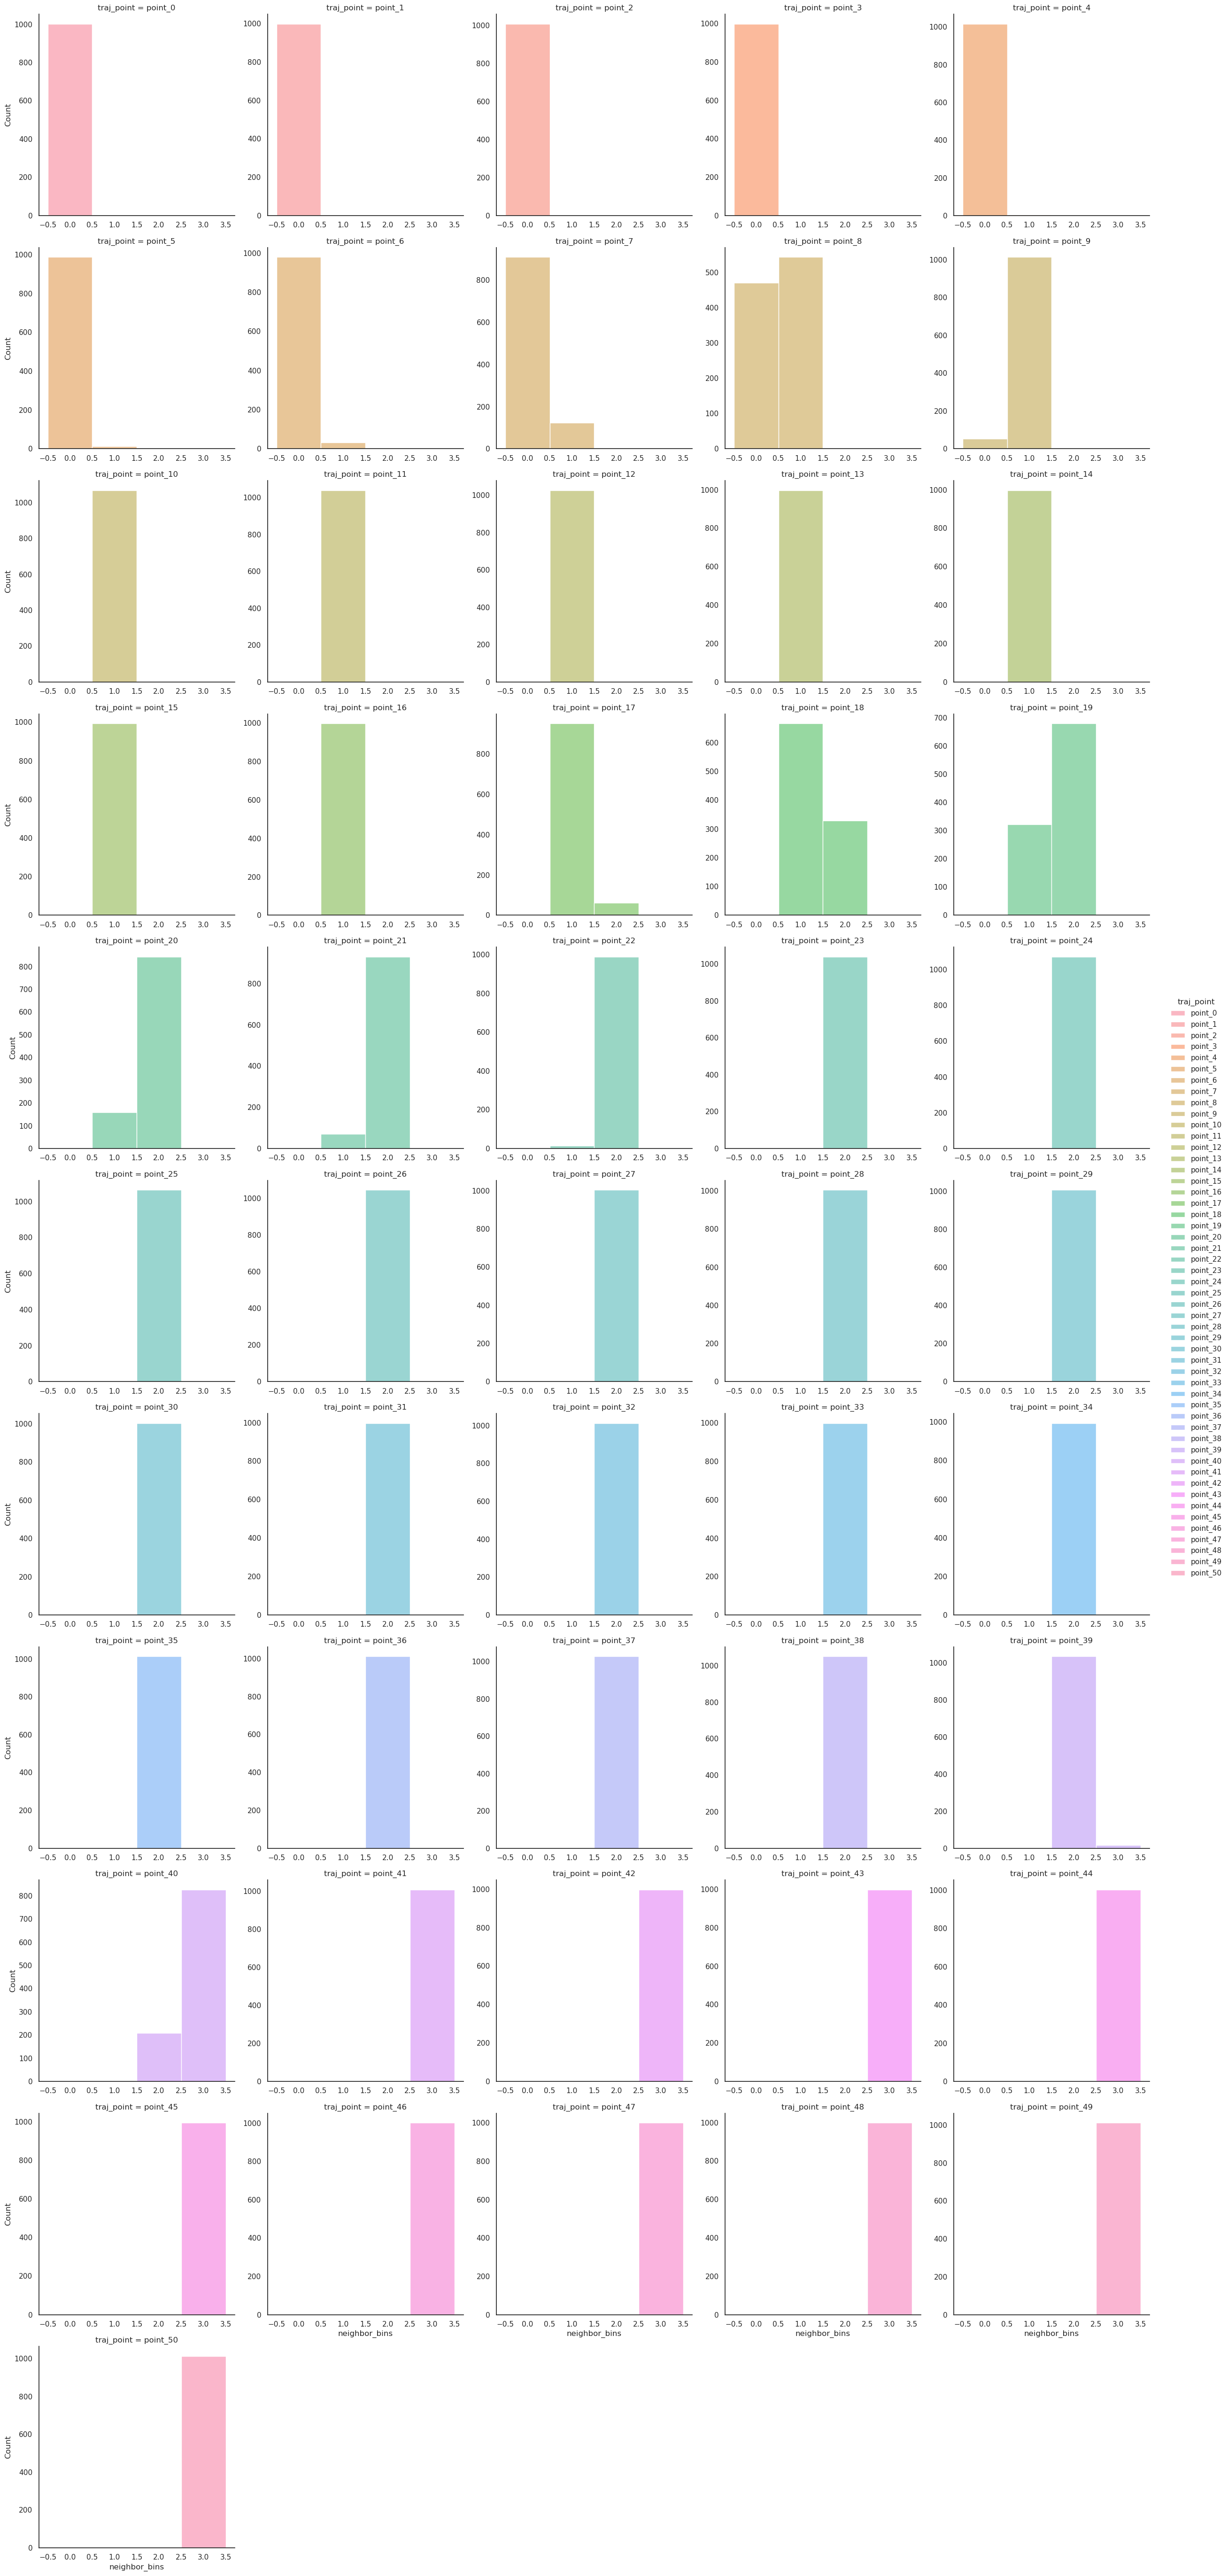

In [63]:
g = sns.displot(data=df_traj_all, x='neighbor_bins', hue='traj_point', col='traj_point', col_wrap=5, fill=True, kind='hist', discrete=True, facet_kws={'sharex': False, 'sharey': False})

In [64]:
print(df_traj_all.columns)

Index(['traj_point', 'orig_index', 'local_density', 'radius', 'pp_value',
       'decoded_cfm', 'neighbor_cfm', 'neighbor_bins'],
      dtype='str')


In [65]:
df_latent

,z_1,z_2,z_3,z_4,z_5,z_6,z_7,z_8,z_9,z_10,label,decoded_cfm
0,-24.256855,-18.943563,-19.148005,-13.069660,-7.281853,-6.647669,-1.973320,1.312754,5.479063,10.920240,2,1.048495
1,-32.498856,-27.973068,-25.985146,-23.571732,-19.487030,-15.888780,-14.033054,-9.226448,-8.665678,-4.734122,3,1.236806
2,-17.562922,-16.157148,-7.969545,-5.897250,1.853780,4.455924,9.762284,14.726957,23.734491,29.096786,2,1.044764
3,-28.858011,-24.174309,-22.691444,-19.941648,-16.066748,-12.556651,-10.494271,-5.782712,-5.136093,-1.035175,3,-0.825561
4,-10.571421,-6.463661,0.640753,7.082870,11.920109,17.315226,24.198599,28.219280,36.607440,41.267610,0,0.690024
...,...,...,...,...,...,...,...,...,...,...,...,...
56645,-28.579952,-23.901604,-22.118683,-19.591473,-15.684873,-12.046993,-10.108648,-5.416104,-4.710186,-0.721344,3,0.267969
56646,-7.582398,-3.366018,3.963249,10.430345,15.107400,20.847500,27.655052,31.937830,40.201540,44.993100,0,-0.972245
56647,-17.119564,-13.705447,-7.196110,-4.540887,3.223161,5.727212,10.905486,15.751303,24.399230,29.637558,2,0.547159
56648,-29.270935,-24.531736,-22.611712,-20.303423,-16.054407,-12.572237,-10.648892,-5.845601,-5.259646,-1.332067,3,1.229240


In [66]:
# cell to make code stop here
raise SystemExit("Stop right there!")

SystemExit: Stop right there!

/home/nghayes/miniforge3/envs/c-gmvae/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3755: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
import pandas as pd
from scipy.stats import gaussian_kde
import numpy as np

sns.set(style="white")

temp = df.copy()

# bin as categorical
bin_order = ['0', '1', '2', '3']
temp["14-6-Bin"] = (
    temp["14-6-Bin"].astype(str)
    .astype(pd.CategoricalDtype(categories=bin_order, ordered=True))
)

# x grid
xs_all = temp["PP"].values
xs_grid = np.linspace(xs_all.min(), xs_all.max(), 400)

# --- compute KDE + peak for each strain ---
strain_info = {}
for strain, sub in temp.groupby("Strain"):
    vals = sub["PP"].values
    kde = gaussian_kde(vals)
    ys = kde(xs_grid)

    idx_peak = np.argmax(ys)
    x_peak = xs_grid[idx_peak]
    y_peak = ys[idx_peak]
    bin_val = sub["14-6-Bin"].iloc[0]

    strain_info[strain] = dict(
        ys=ys,
        x_peak=x_peak,
        y_peak=y_peak,
        bin=bin_val
    )

# --- color by peak order using coolwarm_r ---
cmap = cm.get_cmap('coolwarm_r')
sorted_strains = sorted(strain_info.keys(), key=lambda s: strain_info[s]["x_peak"])
n_strains = len(sorted_strains)

strain_colors = {}
for i, strain in enumerate(sorted_strains):
    if n_strains > 1:
        frac = i / (n_strains - 1)     # 0 → 1
    else:
        frac = 0.5
    strain_colors[strain] = cmap(frac)

# --- plotting ---
plt.figure(figsize=(8,4))

for strain in sorted_strains:
    info = strain_info[strain]
    ys = info["ys"]
    x_peak = info["x_peak"]
    y_peak = info["y_peak"]

    color = strain_colors[strain]

    plt.fill_between(xs_grid, ys, color=color, alpha=0.25)
    plt.plot(xs_grid, ys, color=color, linewidth=1.5)

    # label on plot (black)
    plt.text(
        x_peak,
        y_peak * 1.15,
        strain,
        fontsize=8,
        ha='center',
        color='black'
    )

# --- legend for strains ---
legend_handles = []
for strain in sorted_strains:
    bin_val = strain_info[strain]["bin"]
    label = f"{strain} (bin {bin_val})"
    patch = Patch(facecolor=strain_colors[strain], label=label)
    legend_handles.append(patch)

plt.legend(
    handles=legend_handles,
    title="Strains",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.xlabel("Phenotypic projection")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig('kde_strain.jpg')
plt.show()


In [ ]:
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import KernelDensity

def compute_kde_peak(values, bandwidth=0.1, grid_size=1000):
    values = values[:, None]
    kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth).fit(values)
    grid = np.linspace(values.min(), values.max(), grid_size)[:, None]
    log_dens = kde.score_samples(grid)
    peak = grid[np.argmax(log_dens)][0]
    return peak

def compute_osd(df, projection_col='PP', bin_col='14-6-Bin', bandwidth=0.1):
    # Step 1: Compute KDE peaks for each bin
    bins_sorted = sorted(df[bin_col].unique())
    peak_locs = []
    for b in bins_sorted:
        values = df[df[bin_col] == b][projection_col].values
        if len(values) > 1:
            peak = compute_kde_peak(values, bandwidth=bandwidth)
        else:
            peak = np.nan
        peak_locs.append(peak)

    rho, _ = spearmanr(bins_sorted, peak_locs)

    D_list = []
    for i in range(len(bins_sorted) - 1):
        b_low, b_high = bins_sorted[i], bins_sorted[i + 1]
        df_pair = df[df[bin_col].isin([b_low, b_high])].copy()
        df_pair['label'] = (df_pair[bin_col] == b_high).astype(int)
        auc = roc_auc_score(df_pair['label'], df_pair[projection_col])
        D = 2 * auc - 1
        D_list.append(D)

    D_avg = np.mean(D_list)
    osd = rho * D_avg
    return {'rho_spearman': rho,'somers_d_adjacent': D_avg,'osd': osd,'peak_locations': dict(zip(bins_sorted, peak_locs)),'pairwise_D': D_list}

In [ ]:
result = compute_osd(df)
print("Spearman ρ:", result['rho_spearman'])
print("Mean Somers' D:", result['somers_d_adjacent'])
print("OSD:", result['osd'])